# Exercise 1: The Driven Pendulum

Remember:<br>
Meaningful variable names<br>
Comments, minimum docstring for each function<br>
Captions and title for plots (semicolon on last line to suppress printed output)<br>
Long-running part of calculation in separate cell to plots, or pickle to save to file

In [8]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

## Core Task 1 

Rewrite second-order differential equation as pair of linked first-order equations in $\theta$ and $\dot{\theta}$ and write a program to integrate them.
<br>

Test by setting $q = F = 0$ starting from $(\theta_{0}, \omega_{0}) = (0.01, 0.0)$ and plot for 10, 100, 1000 ... periods, overlay onto expected theoretical result for small angles
<br>

Test for conservation of energy, plot energy vs time for 10,000 oscillations. Plot period T vs amplitude of oscillation up to $\pi$
<br>



In [9]:
# Import the integrator used
from scipy.integrate import odeint

In [10]:
# Define variables and initial conditions
g = l = 9.81
q = 0
F = 0
driving_freq = 2/3
T0 = 2*np.pi # Natural oscillation frequency

y0_0 = 0.01 # Initial displacement
y1_0 = 0.0 # Initial angular velocity, starts at rest
y_initial = [y0_0, y1_0] # Vector of intial conditions

### Implementing the odeint integrator

After rewriting the equation as two first order equations in y0 = theta and y1 = theta_dot, we use the integrator odeint from scipy.integrate to solve the equations.
<br>
The odeint function takes in (minimum) three arguments: odeint(equations, y_initial, t)
1) equations is a function which takes in a vector [y0, y1, y2, ...] and returns a list the terms equal to the derivatives of each element, which provides the equations to be solved
2) y_intial is a list of initial conditions [y0_0, y1_0, ...]
3) t is the parameter the derivatives are taken with respect to

In [11]:
# Defining the first-order equations to be solved
def equations(y, t):
    y0, y1 = y
    dy0 = y1
    dy1 = -g/l * np.sin(y0) - q*y1 + F*np.sin(driving_freq*t)
    return [dy0, dy1]

In [36]:
# Solving the equations. odeint returns an array with two columns, the first being y0 and the second being y1
# Plot for 1000 periods of oscillation

t = np.arange(0, 10000*T0, 0.1) # Solve for up to 10 seconds
sol = odeint(equations, y_initial, t)

In [37]:
# Separate displacement and velocity components
theta = sol[:,0]
omega = sol[:,1]

In [38]:
# Take m = 1 so that E = 0.5*omega**2 + g*h, h = 1-cos(theta)
total_energy = 0.5*(l**2)*(omega**2) + g*l*(1-np.cos(theta))
total_energy = total_energy/total_energy[0]

Text(0.5, 1.0, 'Energy vs time')

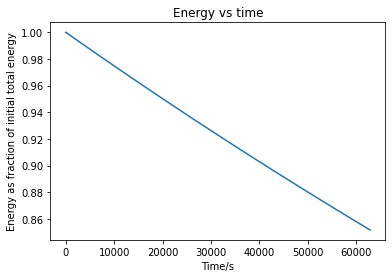

In [39]:
plt.plot(t, total_energy)
plt.xlabel("Time/s")
plt.ylabel("Energy as fraction of initial total energy")
plt.title("Energy vs time")

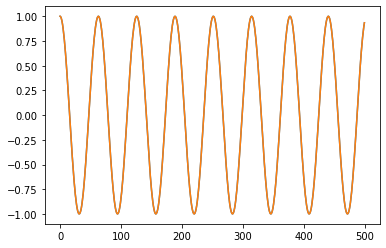

In [33]:
plt.plot(theta[:500]/theta[0])
plt.plot(np.cos(t)[:500])

In [32]:
sol[0]

array([0.01, 0.  ])